Fear & Greed Sentiment Analysis on Cryptocurrency Trading Performancetext

In [78]:
# ---------------------------
# Final Project Summary
# -----------------------------

print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("\n1. Historical trades analysed :", len(trades))
print("2. Fear & Greed records        :", len(sentiment))
print("3. Merged dataset size         :", len(merged))

print("\nAverage Closed PnL:")
print(round(merged["Closed PnL"].mean(),2))

print("\nTotal Profit:")
print(round(merged["Closed PnL"].sum(),2))

print("\nMarket Sentiment Distribution:")
print(merged["classification"].value_counts())

print("\nAverage Closed PnL by Market Sentiment:")
print(merged.groupby("classification")["Closed PnL"].mean())

print("\nWin Rate by Market Sentiment (%):")
win_rate = pd.crosstab(
    merged["classification"],
    merged["Result"],
    normalize="index"
) * 100

print(win_rate)

print("\nCorrelation Matrix:")
print(merged.select_dtypes(include="number").corr())

print("\nAnalysis Completed Successfully!")

PROJECT SUMMARY

1. Historical trades analysed : 211224
2. Fear & Greed records        : 2644
3. Merged dataset size         : 211224

Average Closed PnL:
48.75

Total Profit:
10296958.94

Market Sentiment Distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Average Closed PnL by Market Sentiment:
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Win Rate by Market Sentiment (%):
Result               Loss     Profit
classification                      
Extreme Fear    62.939252  37.060748
Extreme Greed   53.505701  46.494299
Fear            57.923250  42.076750
Greed           61.517206  38.482794
Neutral         60.300907  39.699093

Correlation Matrix:
                 Execution Price  Size Tokens  Size USD  Start Position  \
Execution 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
# Load the datasets

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [4]:
print("Historical Data Shape:", trades.shape)
print("Fear Greed Shape:", sentiment.shape)

Historical Data Shape: (211224, 16)
Fear Greed Shape: (2644, 4)


In [29]:
print("Historical Data")
trades.head()

Historical Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [30]:
print('Trades Date Range:', trades['Timestamp IST'].min(), '-', trades['Timestamp IST'].max())
print('Sentiment Date Range:', sentiment['date'].min(), '-', sentiment['date'].max())

Trades Date Range: 2023-05-01 01:06:00 - 2025-05-01 12:13:00
Sentiment Date Range: 2018-02-01 00:00:00 - 2025-05-02 00:00:00


### Daily Trade Volume Calculation

In [31]:
# Extract date from 'Timestamp IST' for daily aggregation
trades['trade_date'] = trades['Timestamp IST'].dt.date

# Calculate daily trade volume (sum of Size USD)
daily_trade_volume = trades.groupby('trade_date')['Size USD'].sum().reset_index()
daily_trade_volume['trade_date'] = pd.to_datetime(daily_trade_volume['trade_date'])

print("Daily Trade Volume:")
display(daily_trade_volume.head())

Daily Trade Volume:


,trade_date,Size USD
0,2023-05-01,477.00
1,2023-12-05,50005.83
2,2023-12-14,113203.35
3,2023-12-15,10609.95
4,2023-12-16,15348.77


### Merging DataFrames and Calculating Correlation

In [32]:
# Merge daily trade volume with sentiment data on date
merged_data = pd.merge(daily_trade_volume, sentiment, left_on='trade_date', right_on='date', how='inner')

print("Merged Data (first 5 rows):")
display(merged_data.head())

# Calculate the correlation between daily trade volume and sentiment value
correlation = merged_data['Size USD'].corr(merged_data['value'])

print(f"\nCorrelation between Daily Trade Volume and Sentiment Value: {correlation:.4f}")

Merged Data (first 5 rows):


,trade_date,Size USD,timestamp,value,classification,date
0,2023-05-01,477.00,1682919000,63,Greed,2023-05-01
1,2023-12-05,50005.83,1701754200,75,Extreme Greed,2023-12-05
2,2023-12-14,113203.35,1702531800,72,Greed,2023-12-14
3,2023-12-15,10609.95,1702618200,70,Greed,2023-12-15
4,2023-12-16,15348.77,1702704600,67,Greed,2023-12-16



Correlation between Daily Trade Volume and Sentiment Value: -0.2644


In [6]:
print("Fear Greed Index")
sentiment.head()

Fear Greed Index


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [10]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [11]:
trades.describe()


,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [12]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

trades.head()

sentiment.head()

trades.info()

sentiment.info()

trades.columns

sentiment.columns

trades.describe()

(211224, 16)
(2644, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dt

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [13]:
# Missing values in Historical Data
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [14]:
# Missing values in Fear & Greed Data
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [15]:
print("Duplicate rows in Historical Data:", trades.duplicated().sum())

print("Duplicate rows in Fear & Greed:", sentiment.duplicated().sum())

Duplicate rows in Historical Data: 0
Duplicate rows in Fear & Greed: 0


In [16]:
trades["Side"].unique()

array(['BUY', 'SELL'], dtype=object)

In [17]:
trades["Direction"].unique()

array(['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion',
       'Open Short', 'Close Short', 'Long > Short', 'Short > Long',
       'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement'],
      dtype=object)

In [18]:
sentiment["classification"].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [24]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], format='%d-%m-%Y %H:%M', errors='coerce')

In [20]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [25]:
trades.dtypes

,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,datetime64[ns]
Start Position,float64
Direction,object
Closed PnL,float64


In [27]:
sentiment.dtypes

,0
timestamp,int64
value,int64
classification,object
date,datetime64[ns]


In [33]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [35]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [36]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [37]:
sentiment["Date"] = sentiment["date"].dt.date

In [38]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='object')


In [39]:
sentiment[["date", "Date"]].head()


,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [42]:
sentiment[["date", "Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [43]:
trades.isnull().sum()

sentiment.isnull().sum()

trades.duplicated().sum()

sentiment.duplicated().sum()

trades["Side"].unique()

trades["Direction"].unique()

sentiment["classification"].unique()

trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])

sentiment["date"] = pd.to_datetime(sentiment["date"])

trades["Date"] = trades["Timestamp IST"].dt.date

sentiment["Date"] = sentiment["date"].dt.date

trades[["Timestamp IST", "Date"]].head()

sentiment[["date", "Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [44]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='object')


In [45]:
sentiment["Date"] = sentiment["date"].dt.date

In [46]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='object')


In [47]:
sentiment[["date", "Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [48]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [49]:
sentiment["Date"] = sentiment["date"].dt.date

In [50]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])

trades["Date"] = trades["Timestamp IST"].dt.date

In [51]:
trades[["Timestamp IST", "Date"]].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [52]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

In [53]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed


In [54]:
merged.shape

(211224, 19)

In [55]:
merged["classification"].isnull().sum()

np.int64(6)

In [56]:
# Count of each market sentiment
merged["classification"].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


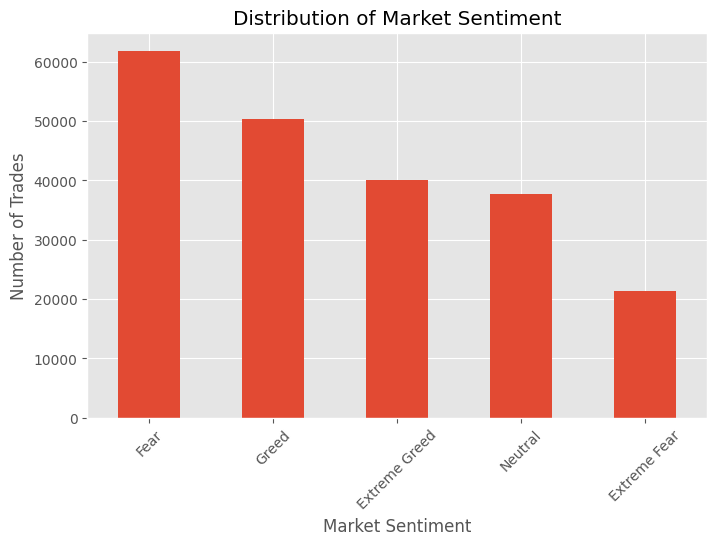

In [57]:
plt.figure(figsize=(8,5))
merged["classification"].value_counts().plot(kind="bar")

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

In [58]:
merged.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


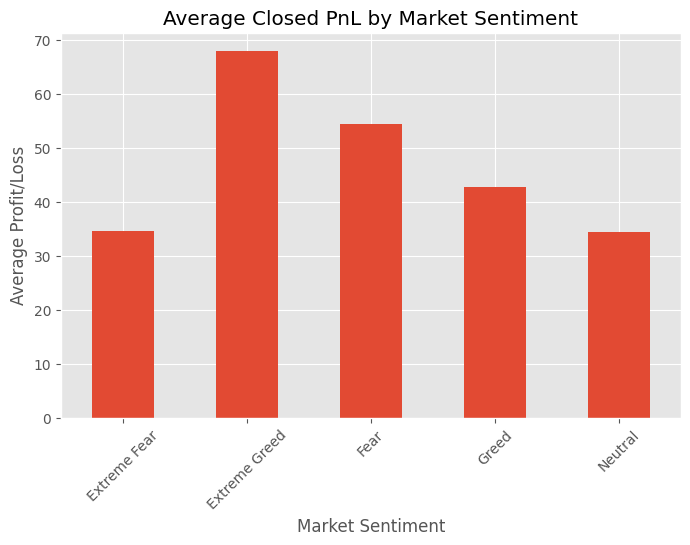

In [59]:
plt.figure(figsize=(8,5))

merged.groupby("classification")["Closed PnL"].mean().plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Profit/Loss")

plt.xticks(rotation=45)

plt.show()

In [60]:
merged.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


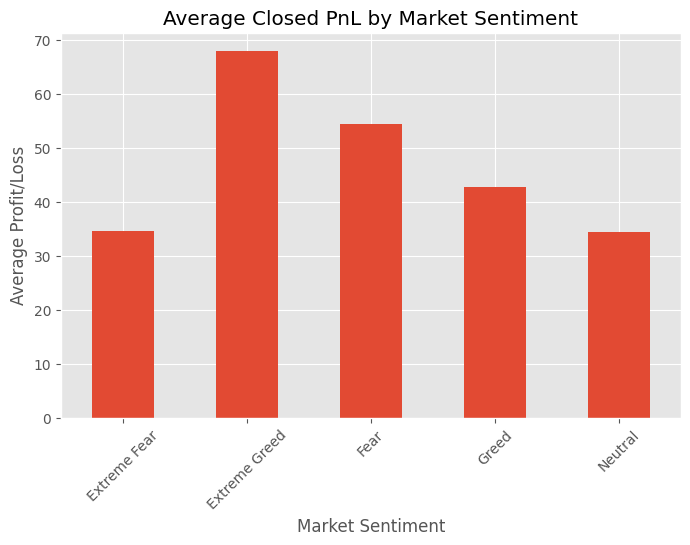

In [61]:
plt.figure(figsize=(8,5))

merged.groupby("classification")["Closed PnL"].mean().plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Profit/Loss")

plt.xticks(rotation=45)

plt.show()

In [62]:
merged.groupby("classification")["Closed PnL"].sum()

,Closed PnL
classification,
Extreme Fear,7.391102e+05
Extreme Greed,2.715171e+06
Fear,3.357155e+06
Greed,2.150129e+06
Neutral,1.292921e+06


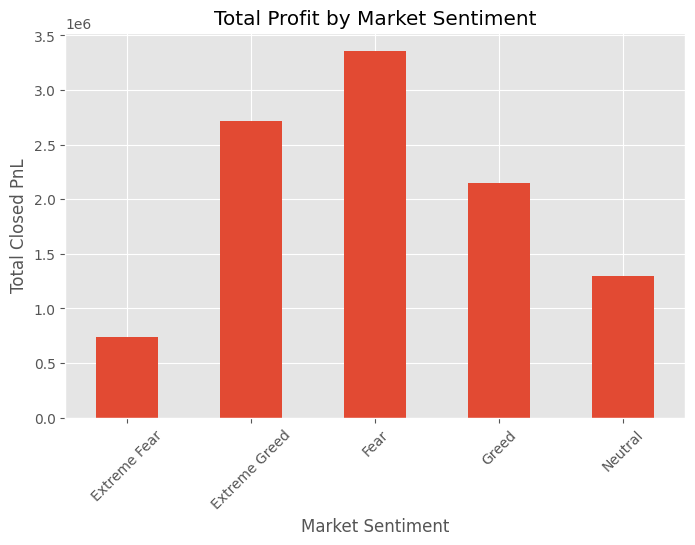

In [63]:
plt.figure(figsize=(8,5))

merged.groupby("classification")["Closed PnL"].sum().plot(kind="bar")

plt.title("Total Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

In [64]:
merged["Trade Result"] = merged["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

In [65]:
merged["Trade Result"].value_counts()

,count
Trade Result,
Loss,124355
Profit,86869


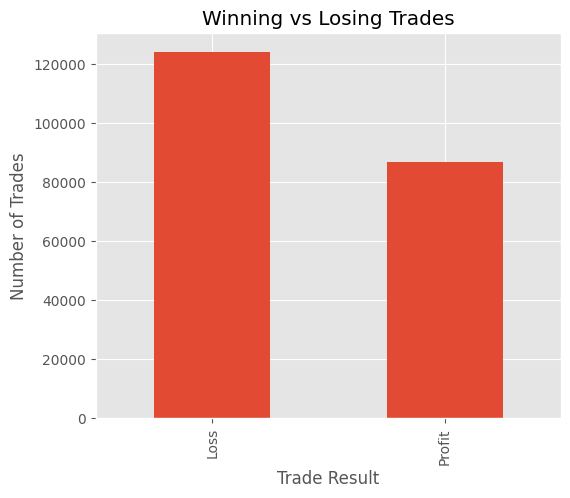

In [66]:
plt.figure(figsize=(6,5))

merged["Trade Result"].value_counts().plot(kind="bar")

plt.title("Winning vs Losing Trades")
plt.ylabel("Number of Trades")

plt.show()

In [68]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'trade_date', 'Date', 'classification', 'Trade Result']


classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


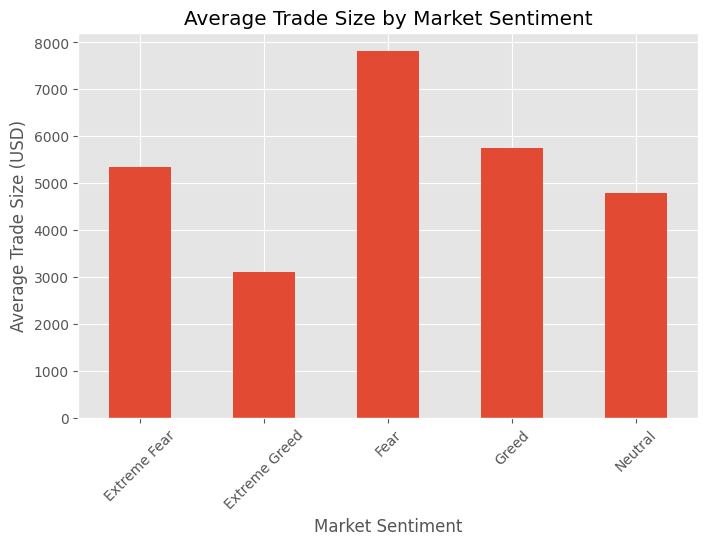

In [71]:
trade_size = merged.groupby("classification")["Size USD"].mean()

print(trade_size)

plt.figure(figsize=(8,5))
trade_size.plot(kind="bar")
plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


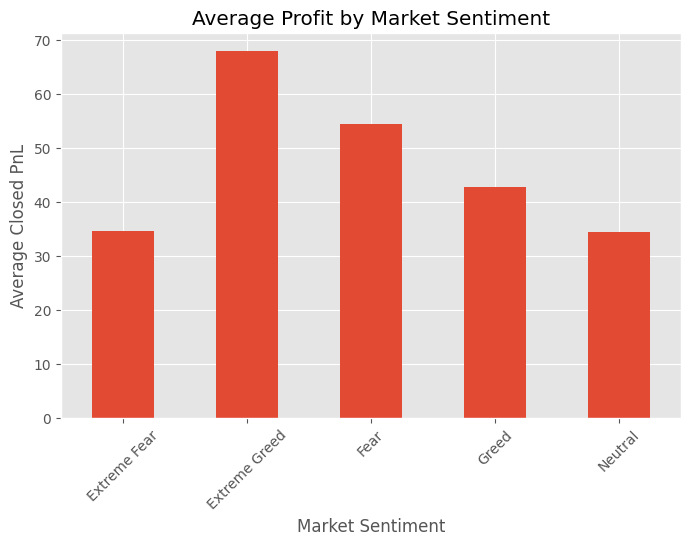

In [72]:
profit = merged.groupby("classification")["Closed PnL"].mean()

print(profit)

plt.figure(figsize=(8,5))
profit.plot(kind="bar")
plt.title("Average Profit by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

Result               Loss     Profit
classification                      
Extreme Fear    62.939252  37.060748
Extreme Greed   53.505701  46.494299
Fear            57.923250  42.076750
Greed           61.517206  38.482794
Neutral         60.300907  39.699093


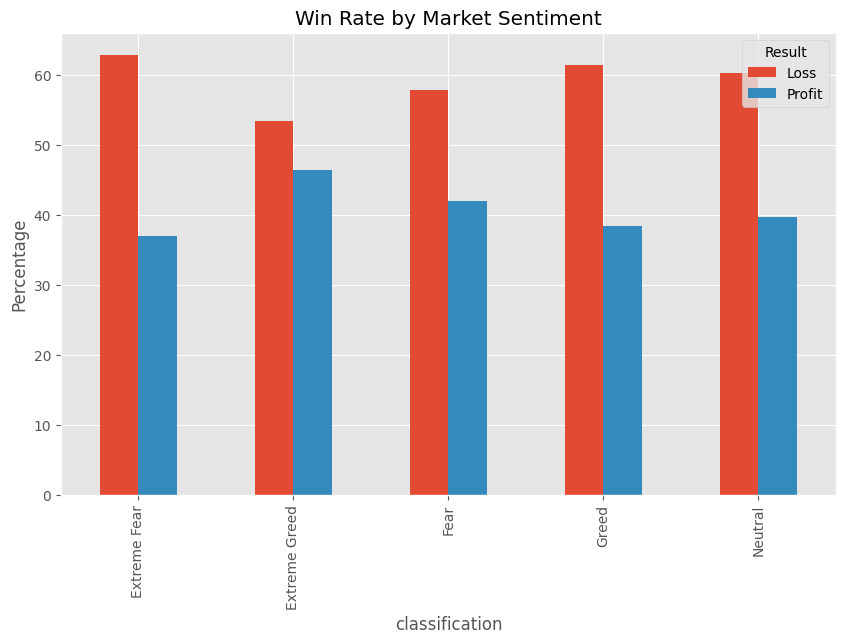

In [73]:
merged["Result"] = merged["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

win_rate = pd.crosstab(
    merged["classification"],
    merged["Result"],
    normalize="index"
) * 100

print(win_rate)

win_rate.plot(kind="bar", figsize=(10,6))
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Percentage")
plt.show()

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


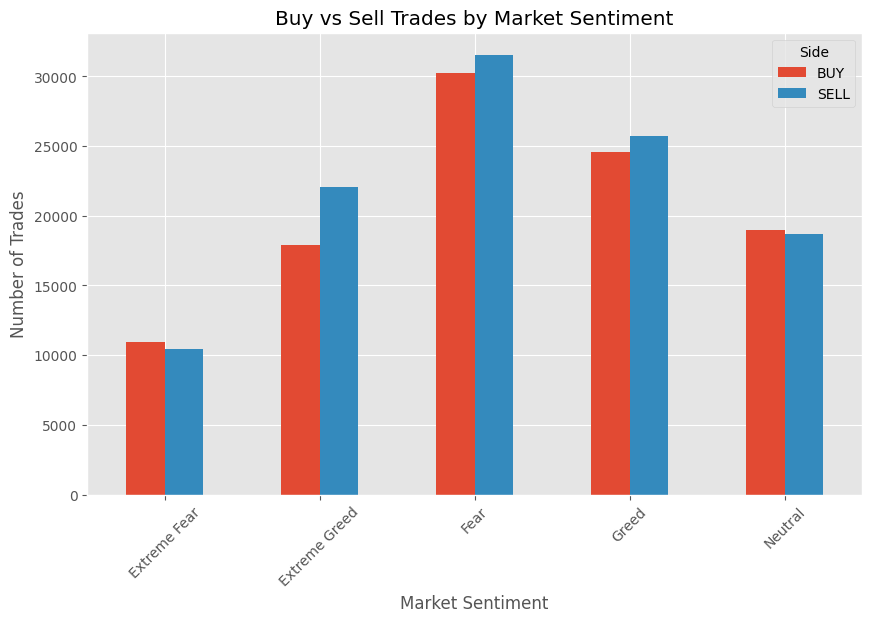

In [74]:
buy_sell = pd.crosstab(
    merged["classification"],
    merged["Side"]
)

print(buy_sell)

buy_sell.plot(kind="bar", figsize=(10,6))
plt.title("Buy vs Sell Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


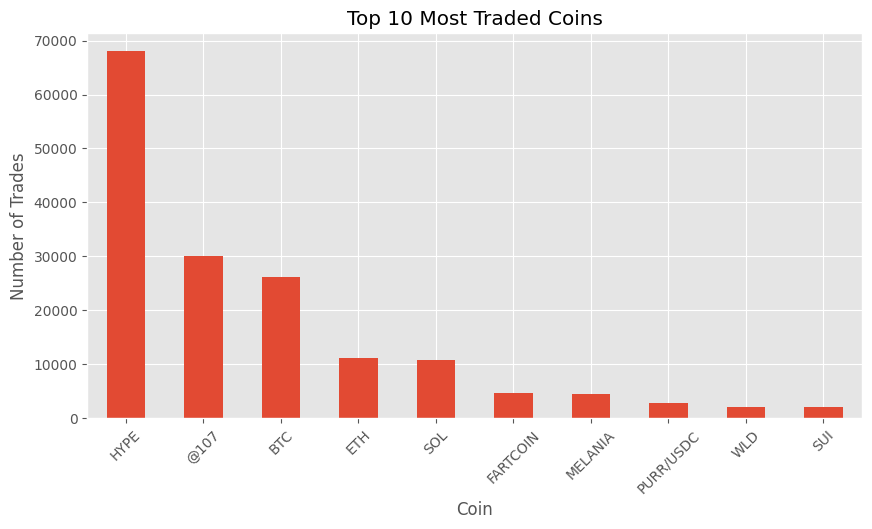

In [75]:
top_coins = merged["Coin"].value_counts().head(10)

print(top_coins)

plt.figure(figsize=(10,5))
top_coins.plot(kind="bar")
plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

Coin
@109       270.704207
AVAX       239.095613
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        153.358519
MOODENG    151.096714
ZRO        148.327509
Name: Closed PnL, dtype: float64


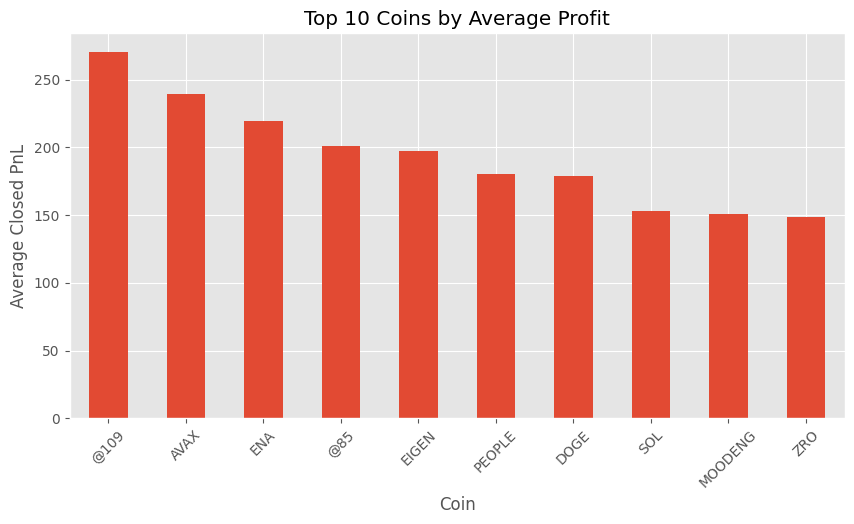

In [76]:
coin_profit = merged.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False).head(10)

print(coin_profit)

plt.figure(figsize=(10,5))
coin_profit.plot(kind="bar")
plt.title("Top 10 Coins by Average Profit")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

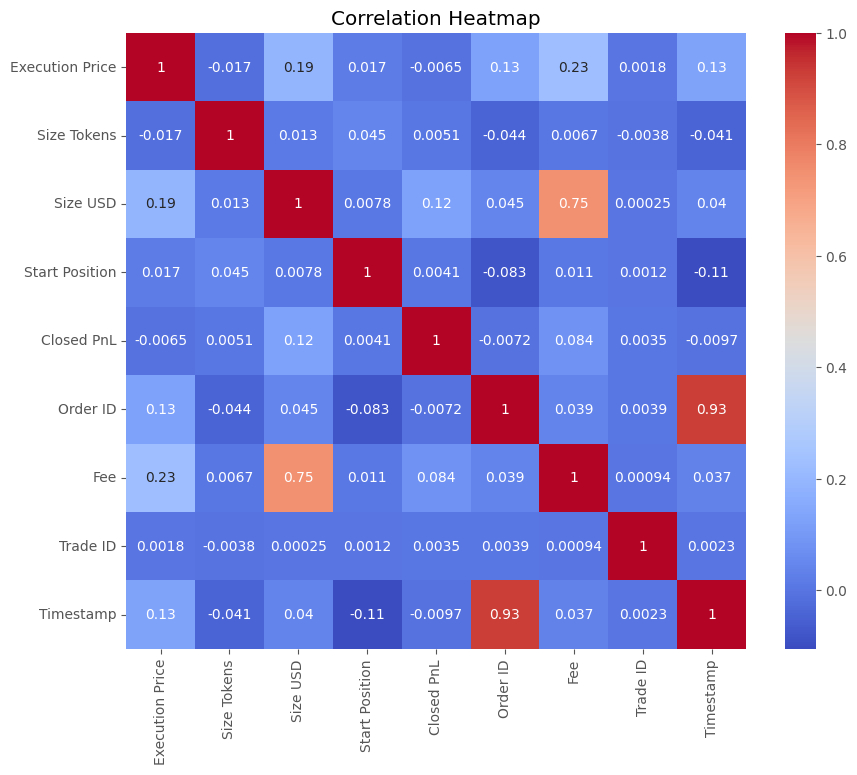

In [77]:
numeric = merged.select_dtypes(include=["float64", "int64"])

correlation = numeric.corr()

plt.figure(figsize=(10,8))
import seaborn as sns

sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [79]:
print(win_rate)

print("\nCorrelation Matrix:")
print(merged.select_dtypes(include="number").corr())

print("\nAnalysis Completed Successfully!")

Result               Loss     Profit
classification                      
Extreme Fear    62.939252  37.060748
Extreme Greed   53.505701  46.494299
Fear            57.923250  42.076750
Greed           61.517206  38.482794
Neutral         60.300907  39.699093

Correlation Matrix:
                 Execution Price  Size Tokens  Size USD  Start Position  \
Execution Price         1.000000    -0.017185  0.189855        0.017241   
Size Tokens            -0.017185     1.000000  0.013310        0.044660   
Size USD                0.189855     0.013310  1.000000        0.007787   
Start Position          0.017241     0.044660  0.007787        1.000000   
Closed PnL             -0.006505     0.005068  0.123589        0.004066   
Order ID                0.125850    -0.043753  0.045210       -0.082799   
Fee                     0.225265     0.006710  0.745939        0.010559   
Trade ID                0.001841    -0.003848  0.000245        0.001165   
Timestamp               0.130714    -0.040949